In [2]:
import pandas as pd
import numpy as np 
import torch 
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("churn_modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
# delete columns that are not needed
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)


In [7]:
df.head(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
# divide our dataset into x and y 

X = df.drop(columns=["Exited"], axis=1)
y = df["Exited"]

print(f"X forma {X.shape}")
print(f"Y shape {y.shape}")


X forma (10000, 10)
Y shape (10000,)


In [14]:
# divide into train and test

from sklearn.model_selection import train_test_split

np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [25]:
# we need to use OneHotEncoding to handle object datatype

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

one_hot = OneHotEncoder(handle_unknown="ignore")
scaler = StandardScaler()

columns = ["Geography", "Gender"]
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()


transformer = ColumnTransformer(
    transformers=[
        ('one_hot', one_hot, columns), # Apply OHE to categorical columns
        ('scaler', scaler, numerical_cols)     # apply Scaler to numeric columns
    ],
    remainder='passthrough' 
)

transformed_x_train = transformer.fit_transform(X_train)

transformed_x_test = transformer.transform(X_test)


print(f"Transformed x test shape {transformed_x_test.shape}")
print(f"Transformed x train shape {transformed_x_train.shape}")

Transformed x test shape (2000, 13)
Transformed x train shape (8000, 13)


In [26]:
'''
we need to use tensor to work with pytorch 
it is a good practice to use float32 for input and output data in neural networks

'''

X_train_tensor = torch.tensor(transformed_x_train.astype(np.float32))
X_test_tensor = torch.tensor(transformed_x_test.astype(np.float32))

'''
convert y to tensors
for BCELoss (binary cross entropy) and BCEwithLogitsLoss, labels must be float 32
.values is added to work with pandas series values
we use unsqueeze(1) to chhange the form of [batch_size] to [batch_size, 1]

'''

y_train_tensor = torch.tensor(y_train.values.astype(np.float32)).unsqueeze(1)
y_test_tensor = torch.tensor(y_test.values.astype(np.float32)).unsqueeze(1)



print(f"Forma X_train_tensor: {X_train_tensor.shape}, Tipo: {X_train_tensor.dtype}")
print(f"Forma y_train_tensor: {y_train_tensor.shape}, Tipo: {y_train_tensor.dtype}")
print(f"Forma X_test_tensor: {X_test_tensor.shape}, Tipo: {X_test_tensor.dtype}")
print(f"Forma y_test_tensor: {y_test_tensor.shape}, Tipo: {y_test_tensor.dtype}")


Forma X_train_tensor: torch.Size([8000, 13]), Tipo: torch.float32
Forma y_train_tensor: torch.Size([8000, 1]), Tipo: torch.float32
Forma X_test_tensor: torch.Size([2000, 13]), Tipo: torch.float32
Forma y_test_tensor: torch.Size([2000, 1]), Tipo: torch.float32


In [28]:
# define the arquitecture of neural network

import torch.nn as nn
import torch.nn.functional as F # it contains commons activations functions

class SimpleNN(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.layer_1 = nn.Linear(input_features, 64)
        self.layer_2 = nn.Linear(64, 32)
        self.output_layer = nn.Linear(32, 1)
    
    def forward(self, x):
        x = F.relu(self.layer_1(x))
        x = F.relu(self.layer_2(x))

        x = self.output_layer(x)
        return x 
    
# determine the number of input features 
input_dims = X_train_tensor.shape[1]
model = SimpleNN(input_features=input_dims)
print(model)

SimpleNN(
  (layer_1): Linear(in_features=13, out_features=64, bias=True)
  (layer_2): Linear(in_features=64, out_features=32, bias=True)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)


In [30]:
''' loss function
BCEWithLogitsLoss is more stable than using sigmoid + BCELoss
'''

loss_fn = nn.BCEWithLogitsLoss()

# Optimizer, Adam is generally used

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


Epoch [10/100], Loss: 0.3325
Epoch [20/100], Loss: 0.3193
Epoch [30/100], Loss: 0.3124
Epoch [40/100], Loss: 0.3033
Epoch [50/100], Loss: 0.2981
Epoch [60/100], Loss: 0.2910
Epoch [70/100], Loss: 0.2856
Epoch [80/100], Loss: 0.2793
Epoch [90/100], Loss: 0.2729
Epoch [100/100], Loss: 0.2696


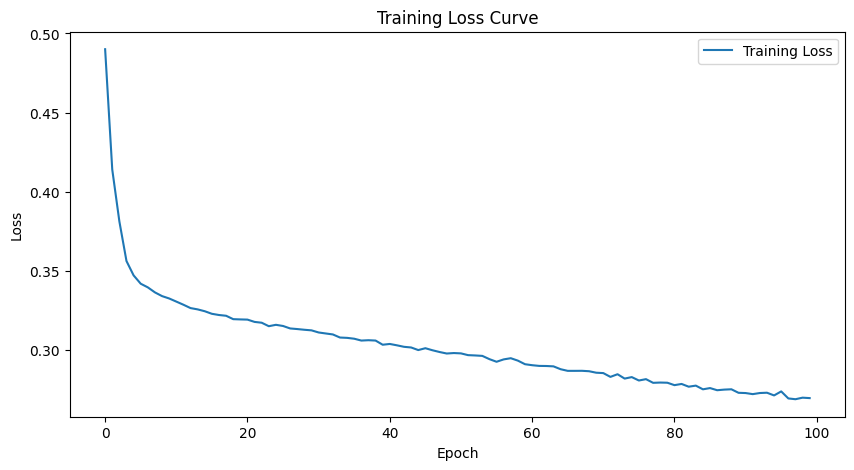

In [36]:
# Training 

epochs = 100
batch_size = 64 
train_losses = []

n_batches = len(X_train_tensor) // batch_size

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    permutation = torch.randperm(X_train_tensor.size()[0])

    for i in range (0, X_train_tensor.size()[0], batch_size):
        optimizer.zero_grad() # clean gradients from last iteration

        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_train_tensor[indices], y_train_tensor[indices]

        # 1. forward pass
        y_pred_logits = model(batch_x)

        # 3. loss calculation
        loss = loss_fn(y_pred_logits, batch_y)
        epoch_loss += loss.item()

        # 3. backward pass 
        loss.backward()

        #4. update weights
        optimizer.step()

    avg_epoch_loss = epoch_loss / n_batches
    train_losses.append(avg_epoch_loss)

    if (epoch + 1) % 10 == 0: # Imprimir cada 10 épocas
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_epoch_loss:.4f}')

# Graficar la pérdida de entrenamiento
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.show()



In [37]:
from sklearn.metrics import accuracy_score, classification_report # Para métricas

model.eval() # Poner el modelo en modo evaluación (desactiva dropout, batchnorm, etc.)
test_losses = []
all_preds = []
all_labels = []

with torch.no_grad(): # Desactivar cálculo de gradientes para evaluación
    # Calcular pérdida en el conjunto de prueba
    test_logits = model(X_test_tensor)
    test_loss = loss_fn(test_logits, y_test_tensor)
    print(f'\nTest Loss: {test_loss.item():.4f}')

    # Calcular métricas de predicción (Accuracy, etc.)
    # 1. Obtener probabilidades aplicando Sigmoid a los logits
    test_probs = torch.sigmoid(test_logits)
    # 2. Convertir probabilidades a predicciones binarias (0 o 1) usando un umbral (e.g., 0.5)
    test_preds = (test_probs > 0.5).float()

    # Mover predicciones y etiquetas a CPU (si estuvieran en GPU) y convertir a NumPy para sklearn
    test_preds_np = test_preds.cpu().numpy()
    y_test_np = y_test_tensor.cpu().numpy()

    # Calcular Accuracy
    accuracy = accuracy_score(y_test_np, test_preds_np)
    print(f'Test Accuracy: {accuracy:.4f}')

    # Mostrar reporte de clasificación más detallado (precisión, recall, f1-score)
    print("\nClassification Report:")
    print(classification_report(y_test_np, test_preds_np))


Test Loss: 0.3679
Test Accuracy: 0.8530

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.94      0.91      1607
         1.0       0.68      0.48      0.56       393

    accuracy                           0.85      2000
   macro avg       0.78      0.71      0.74      2000
weighted avg       0.84      0.85      0.84      2000

